In [2]:
# ─────────────────────────────────────────────
# [C1] 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas scipy statsmodels matplotlib seaborn scikit-learn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf   # 수식(formula)으로 회귀를 쓰는 인터페이스
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지


warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다.
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    # 리눅스·Colab에서 한글이 □□로 보이면 아래를 먼저 실행하세요.
    # !apt-get -qq install -y fonts-nanum && rm -rf ~/.cache/matplotlib
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료!")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("scipy :", scipy.__version__)

준비 완료!
numpy : 2.4.6
pandas: 3.0.3
scipy : 1.17.1


In [3]:
# [C2] ── 데이터 로드 — 모두 라이브러리가 제공하는 데이터셋 ─────────────
from sklearn.datasets import load_diabetes

# (1) scikit-learn 내장: 질병 진행도 (설명변수는 표준화되어 있음)
dia = load_diabetes(as_frame=True)
df = dia.frame                       # 컬럼: age sex bmi bp s1..s6 target

# (2) statsmodels 내장: 소득 → 식료품 지출 (단위가 살아 있는 데이터)
engel = sm.datasets.engel.load_pandas().data          # income, foodexp (벨기에 프랑)

# (3) statsmodels 내장: 거시경제 (다중공선성 교과서)
longley = sm.datasets.longley.load_pandas().data

# (4) Rdatasets: 캘리포니아 학군 420곳
ca = sm.datasets.get_rdataset("CASchools", "AER").data.copy()
ca["testscr"] = (ca["read"] + ca["math"]) / 2          # 읽기·수학 평균 점수 (결과 변수)
ca["str_ratio"] = ca["students"] / ca["teachers"]      # 학생-교사비 (교사 1명당 학생 수)

print("diabetes :", df.shape, "| 컬럼:", list(df.columns))
print("engel    :", engel.shape, "| 컬럼:", list(engel.columns),
      f"| 소득 평균 {engel['income'].mean():.0f}, 식료품 지출 평균 {engel['foodexp'].mean():.0f}")
print("CASchools:", ca.shape, "| 점수 평균 %.1f, 학생-교사비 평균 %.1f"
      % (ca["testscr"].mean(), ca["str_ratio"].mean()))
print("longley  :", longley.shape, "| 컬럼:", list(longley.columns))
print()
print("diabetes 미리보기:")
print(df[["age", "bmi", "bp", "s5", "target"]].head().round(3))

diabetes : (442, 11) | 컬럼: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']
engel    : (235, 2) | 컬럼: ['income', 'foodexp'] | 소득 평균 982, 식료품 지출 평균 624
CASchools: (420, 16) | 점수 평균 654.2, 학생-교사비 평균 19.6
longley  : (16, 7) | 컬럼: ['TOTEMP', 'GNPDEFL', 'GNP', 'UNEMP', 'ARMED', 'POP', 'YEAR']

diabetes 미리보기:
     age    bmi     bp     s5  target
0  0.038  0.062  0.022  0.020   151.0
1 -0.002 -0.051 -0.026 -0.068    75.0
2  0.085  0.044 -0.006  0.003   141.0
3 -0.089 -0.012 -0.037  0.023   206.0
4  0.005 -0.036  0.022 -0.032   135.0


Pearson  r = 0.586  (p = 3.47e-42)   선형 관계의 세기
Spearman ρ = 0.561  (p = 4.57e-38)   순위 관계의 세기


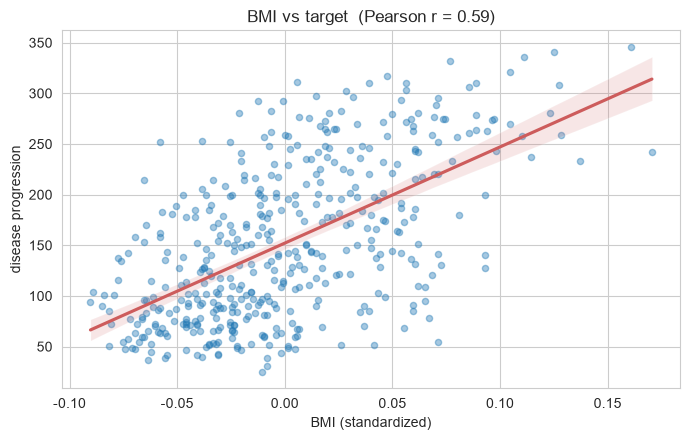

In [4]:
# [C3] diabetes: bmi와 질병 진행도(target)의 상관 — Pearson vs Spearman
x = df["bmi"]; y = df["target"]
r_p, p_p = stats.pearsonr(x, y)                                   # Pearson 상관 — '직선' 관계의 세기 (-1~1)
r_s, p_s = stats.spearmanr(x, y)                                  # Spearman 상관 — 순위 기반, 곡선이어도 단조면 잡아냄
print(f"Pearson  r = {r_p:.3f}  (p = {p_p:.2e})   선형 관계의 세기")
print(f"Spearman ρ = {r_s:.3f}  (p = {p_s:.2e})   순위 관계의 세기")

fig, ax = plt.subplots(figsize=(7, 4.5))                          # 그래프 하나를 그릴 도화지 준비
sns.regplot(x=x, y=y, ax=ax, scatter_kws=dict(alpha=0.4, s=20), line_kws=dict(color="indianred"))  # 산점도 + 회귀선을 한 번에
ax.set_xlabel("BMI (standardized)"); ax.set_ylabel("disease progression")
ax.set_title(f"BMI vs target  (Pearson r = {r_p:.2f})")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

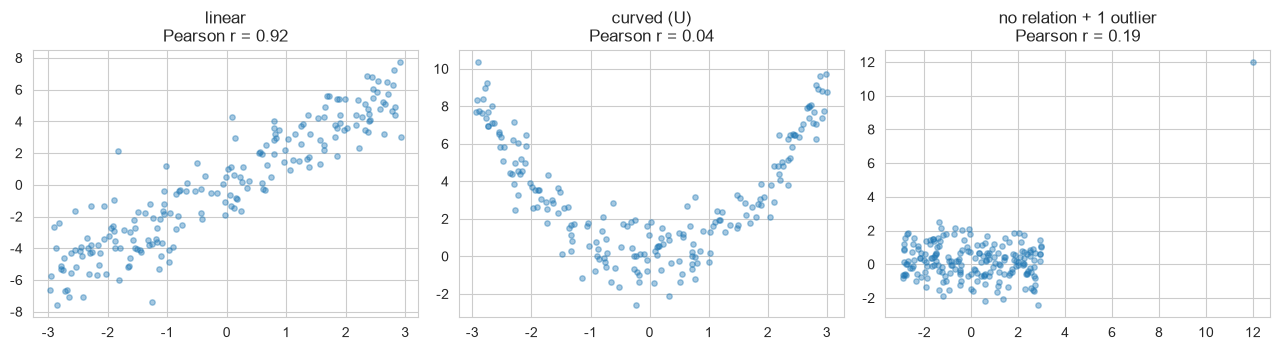

In [5]:
# [C4] 상관계수의 함정 — 같은 r=0 근처라도 관계는 천차만별 (개념 시연)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
n = 200
x1 = np.random.uniform(-3, 3, n); y1 = 2*x1 + np.random.normal(0, 1.5, n)   # 선형
x2 = np.random.uniform(-3, 3, n); y2 = x2**2 + np.random.normal(0, 1, n)    # 곡선(U자)
x3 = np.random.uniform(-3, 3, n); y3 = np.random.normal(0, 1, n)            # 무관계
x3[0], y3[0] = 12, 12                                                       # 이상치 1개

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))                 # 그림 한 장에 그래프 3개(1행 3열)
for ax, xx, yy, t in zip(axes, [x1, x2, x3], [y1, y2, y3],
                         ["linear", "curved (U)", "no relation + 1 outlier"]):
    ax.scatter(xx, yy, alpha=0.4, s=15)
    ax.set_title(f"{t}\nPearson r = {stats.pearsonr(xx, yy)[0]:.2f}")  # Pearson 상관 — '직선' 관계의 세기 (-1~1)
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

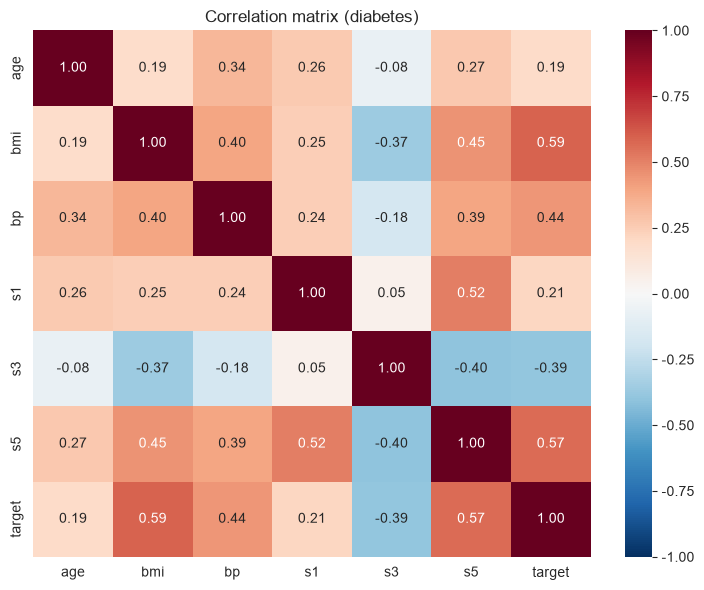

In [6]:
# [C5] 여러 변수의 상관을 한눈에 — 상관 행렬 히트맵 (이해 후 탐색이므로 seaborn)
corr = df[["age", "bmi", "bp", "s1", "s3", "s5", "target"]].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))                          # 그래프 하나를 그릴 도화지 준비
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)  # 상관 행렬을 색으로 — 진할수록 강한 상관
ax.set_title("Correlation matrix (diabetes)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

Pearson  r = 0.836   (곡선이라 다소 과소평가)
Spearman ρ = 0.959   (단조 증가를 강하게 포착)


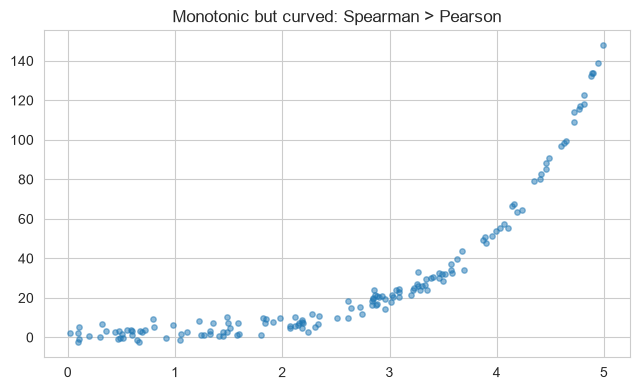

In [7]:
# [C6] 단조-비선형 관계: Pearson은 과소평가, Spearman은 제대로 잡는다
np.random.seed(0)                                                 # 재현성: 난수를 항상 같게 고정
x = np.sort(np.random.uniform(0, 5, 150))
y = np.exp(x) + np.random.normal(0, 3, 150)     # 지수적으로 증가 (곡선이지만 단조 증가)
print(f"Pearson  r = {stats.pearsonr(x, y)[0]:.3f}   (곡선이라 다소 과소평가)")  # Pearson 상관 — '직선' 관계의 세기 (-1~1)
print(f"Spearman ρ = {stats.spearmanr(x, y)[0]:.3f}   (단조 증가를 강하게 포착)")  # Spearman 상관 — 순위 기반, 곡선이어도 단조면 잡아냄
fig, ax = plt.subplots(figsize=(6.5, 4)); ax.scatter(x, y, alpha=0.5, s=15)  # 그래프 하나를 그릴 도화지 준비
ax.set_title("Monotonic but curved: Spearman > Pearson"); plt.tight_layout(); plt.show()  # 그래프 간격 자동 정리 후 출력

In [8]:
# 1) diabetes에서 혈압(bp)과 질병 진행도(target)의 Pearson·Spearman 상관
from scipy import stats

pearson_r, pearson_p = stats.pearsonr(df["bp"], df["target"])
spearman_r, spearman_p = stats.spearmanr(df["bp"], df["target"])

print(f"Pearson  상관계수: r = {pearson_r:.4f}, p-value = {pearson_p:.4e}")
print(f"Spearman 상관계수: r = {spearman_r:.4f}, p-value = {spearman_p:.4e}")

Pearson  상관계수: r = 0.4415, p-value = 1.6494e-22
Spearman 상관계수: r = 0.4162, p-value = 5.9928e-20


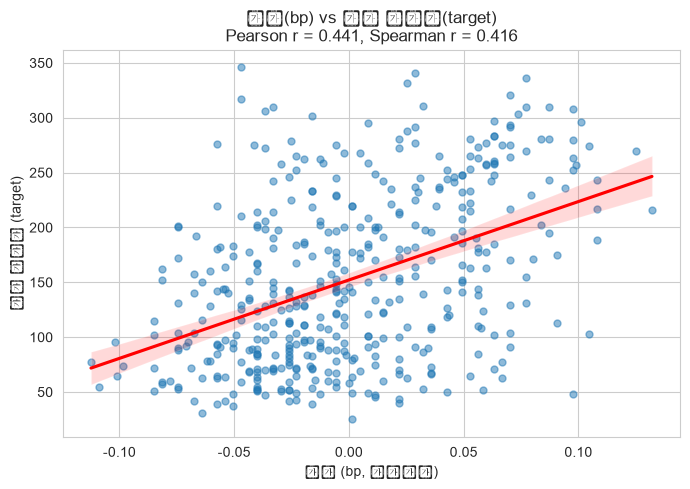

In [9]:
# 2) 산점도(regplot)로 두 변수의 관계 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.regplot(
    data=df,
    x="bp",
    y="target",
    scatter_kws={"alpha": 0.5, "s": 25},
    line_kws={"color": "red"}
)
plt.title(f"혈압(bp) vs 질병 진행도(target)\nPearson r = {pearson_r:.3f}, Spearman r = {spearman_r:.3f}")
plt.xlabel("혈압 (bp, 표준화됨)")
plt.ylabel("질병 진행도 (target)")
plt.tight_layout()
plt.show()

In [10]:
# [C8] 허위상관 시뮬레이션 — 교란변수 Z가 X와 Y를 동시에 움직인다 (개념 시연)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
n = 300
Z = np.random.normal(0, 1, n)            # 숨은 공통 원인 (예: 기온)
X = 2*Z + np.random.normal(0, 0.5, n)    # 아이스크림 판매  (Z가 원인)
Y = 3*Z + np.random.normal(0, 0.5, n)    # 익사 사고 수      (Z가 원인)
# X와 Y 사이에는 '직접' 인과가 없지만...
r_xy = stats.pearsonr(X, Y)[0]                                    # Pearson 상관 — '직선' 관계의 세기 (-1~1)
print(f"X(아이스크림)와 Y(익사)의 상관 r = {r_xy:.3f}  ← 매우 강함!")
print("그러나 X→Y 직접 인과는 없습니다. 둘 다 Z(기온)가 움직인 결과일 뿐.")

# Z의 구간별로 나눠 보면 X-Y 관계가 사라진다 (Z를 '통제'하면)
g = pd.qcut(Z, 3, labels=["저", "중", "고"])                         # 값을 같은 크기의 구간으로 나눠 범주화
for lvl in ["저", "중", "고"]:
    mask = (g == lvl)
    print(f"  Z={lvl} 구간 안에서 X-Y 상관 = {stats.pearsonr(X[mask], Y[mask])[0]:.3f}")  # Pearson 상관 — '직선' 관계의 세기 (-1~1)

X(아이스크림)와 Y(익사)의 상관 r = 0.956  ← 매우 강함!
그러나 X→Y 직접 인과는 없습니다. 둘 다 Z(기온)가 움직인 결과일 뿐.
  Z=저 구간 안에서 X-Y 상관 = 0.845
  Z=중 구간 안에서 X-Y 상관 = 0.567
  Z=고 구간 안에서 X-Y 상관 = 0.894


In [11]:
# [C9] 단순 회귀 — BMI로 질병 진행도 설명 (statsmodels OLS)
X = sm.add_constant(df["bmi"])      # 절편(beta0)을 위해 상수항 추가
y = df["target"]
model = sm.OLS(y, X).fit()                                        # 최소제곱 회귀 적합
print(model.summary().tables[1])     # 계수 표
print(f"\nR² = {model.rsquared:.3f}   (질병 진행도 변동의 약 {model.rsquared*100:.0f}%를 BMI가 설명)")
print(f"기울기 β1 = {model.params['bmi']:.1f}  → BMI가 1(표준화 단위) 늘면 진행도가 평균 {model.params['bmi']:.0f} 증가")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.974     51.162      0.000     146.289     157.978
bmi          949.4353     62.515     15.187      0.000     826.570    1072.301

R² = 0.344   (질병 진행도 변동의 약 34%를 BMI가 설명)
기울기 β1 = 949.4  → BMI가 1(표준화 단위) 늘면 진행도가 평균 949 증가


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        147.4754     15.957      9.242      0.000     116.037     178.914
income         0.4852      0.014     33.772      0.000       0.457       0.513

회귀식: 식료품지출 = 147.5 + 0.485 × 소득
해석  : 소득이 **100프랑** 늘면 식료품 지출은 평균 **48.5프랑** 늘어난다
        (소득이 0일 때의 예측 지출 = 147프랑 — 기초 식비에 해당하는 절편)
R² = 0.830  → 식료품 지출 변동의 약 83%를 소득이 설명

[엥겔의 법칙 확인] 식료품 지출이 소득에서 차지하는 비중
  소득 하위 절반: 68.6%   소득 상위 절반: 62.5%


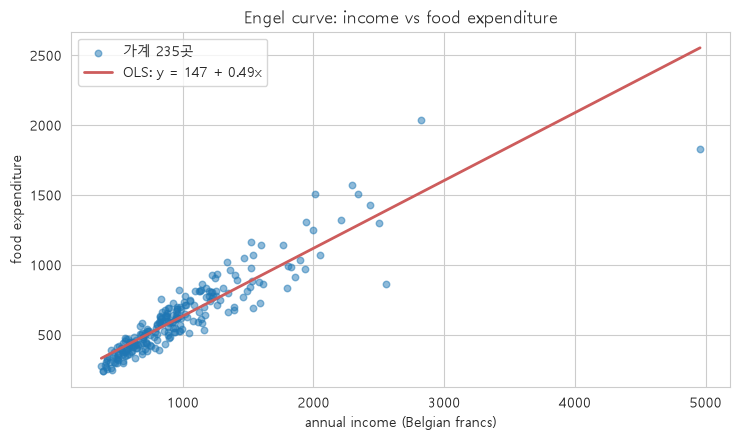

In [12]:
plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# [C9b] 단순 회귀 — 소득으로 식료품 지출 설명 (단위가 있는 실데이터)
Xe = sm.add_constant(engel["income"])                             # 절편(β0)을 위해 상수항 1 열을 추가
me = sm.OLS(engel["foodexp"], Xe).fit()                           # 최소제곱 회귀 적합
print(me.summary().tables[1])                                     # 회귀 결과에서 '계수 표'만 출력

b0, b1 = me.params["const"], me.params["income"]
print(f"\n회귀식: 식료품지출 = {b0:.1f} + {b1:.3f} × 소득")
print(f"해석  : 소득이 **100프랑** 늘면 식료품 지출은 평균 **{b1*100:.1f}프랑** 늘어난다")
print(f"        (소득이 0일 때의 예측 지출 = {b0:.0f}프랑 — 기초 식비에 해당하는 절편)")
print(f"R² = {me.rsquared:.3f}  → 식료품 지출 변동의 약 {me.rsquared*100:.0f}%를 소득이 설명")

# 엥겔의 법칙: 소득이 늘수록 '식료품 비중'은 줄어드는가?
share_low  = (engel.loc[engel["income"] <= engel["income"].median(), "foodexp"]
              / engel.loc[engel["income"] <= engel["income"].median(), "income"]).mean()
share_high = (engel.loc[engel["income"] >  engel["income"].median(), "foodexp"]
              / engel.loc[engel["income"] >  engel["income"].median(), "income"]).mean()
print(f"\n[엥겔의 법칙 확인] 식료품 지출이 소득에서 차지하는 비중")
print(f"  소득 하위 절반: {share_low:.1%}   소득 상위 절반: {share_high:.1%}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))                        # 그래프 하나를 그릴 도화지 준비
ax.scatter(engel["income"], engel["foodexp"], alpha=0.5, s=22, label="가계 235곳")
xs = np.linspace(engel["income"].min(), engel["income"].max(), 100)  # 구간을 균등 간격으로 쪼갠 x축 값
ax.plot(xs, b0 + b1 * xs, color="indianred", lw=2, label=f"OLS: y = {b0:.0f} + {b1:.2f}x")
ax.set_xlabel("annual income (Belgian francs)"); ax.set_ylabel("food expenditure")
ax.set_title("Engel curve: income vs food expenditure"); ax.legend()
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

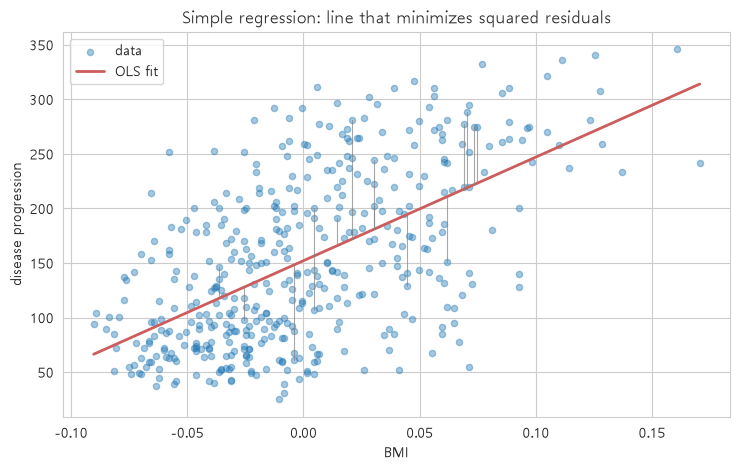

In [13]:
# [C10] 회귀선과 데이터, 그리고 '오차(잔차)'를 함께 그려보기
fig, ax = plt.subplots(figsize=(7.5, 4.8))                        # 그래프 하나를 그릴 도화지 준비
ax.scatter(df["bmi"], y, alpha=0.4, s=20, label="data")
xs = np.linspace(df["bmi"].min(), df["bmi"].max(), 100)           # 구간을 균등 간격으로 쪼갠 x축 값
ax.plot(xs, model.params["const"] + model.params["bmi"]*xs, color="indianred", lw=2, label="OLS fit")
# 잔차(점에서 선까지의 세로 거리) 몇 개를 표시
for i in range(0, len(df), 30):
    xi, yi = df["bmi"].iloc[i], y.iloc[i]
    yhat = model.params["const"] + model.params["bmi"]*xi
    ax.plot([xi, xi], [yi, yhat], color="gray", lw=0.8, alpha=0.7)
ax.set_xlabel("BMI"); ax.set_ylabel("disease progression"); ax.legend()
ax.set_title("Simple regression: line that minimizes squared residuals")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

In [14]:
# [C11] 새 입력에 대한 예측 — 평균 신뢰구간 vs 예측구간
Xs = sm.add_constant(df["bmi"]); ms = sm.OLS(df["target"], Xs).fit()  # 절편(β0)을 위해 상수항 1 열을 추가
q = df["bmi"].quantile([0.25, 0.5, 0.75]).values                  # 분위수 — 정렬했을 때 몇 % 지점의 값
new = pd.DataFrame({"const": [1.0]*3, "bmi": q})
pr = ms.get_prediction(new).summary_frame(alpha=0.05)
out = pd.DataFrame({
    "bmi": q.round(3),
    "예측 ŷ": pr["mean"].round(1),
    "평균 95%CI": [f"[{l:.0f}, {u:.0f}]" for l, u in zip(pr["mean_ci_lower"], pr["mean_ci_upper"])],
    "예측구간": [f"[{l:.0f}, {u:.0f}]" for l, u in zip(pr["obs_ci_lower"], pr["obs_ci_upper"])],
})
print(out.to_string(index=False))
print("\n→ 예측구간(개인)이 평균 신뢰구간보다 훨씬 넓은 것을 확인하세요.")

   bmi  예측 ŷ   평균 95%CI      예측구간
-0.034 119.6 [112, 127] [-3, 243]
-0.007 145.2 [139, 151] [22, 268]
 0.031 181.8 [175, 189] [59, 305]

→ 예측구간(개인)이 평균 신뢰구간보다 훨씬 넓은 것을 확인하세요.


In [15]:
# [C9-2] 단순 회귀 — s5(혈청 지표)로 질병 진행도 설명 (statsmodels OLS)
X_s5 = sm.add_constant(df["s5"])    # 절편(beta0)을 위해 상수항 추가
y = df["target"]
model_s5 = sm.OLS(y, X_s5).fit()                                   # 최소제곱 회귀 적합
print(model_s5.summary().tables[1])  # 계수 표
print(f"\nR² = {model_s5.rsquared:.3f}   (질병 진행도 변동의 약 {model_s5.rsquared*100:.0f}%를 s5가 설명)")
print(f"기울기 β1 = {model_s5.params['s5']:.1f}  → s5가 1(표준화 단위) 늘면 진행도가 평균 {model_s5.params['s5']:.0f} 증가")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      3.027     50.263      0.000     146.185     158.082
s5           916.1374     63.634     14.397      0.000     791.072    1041.202

R² = 0.320   (질병 진행도 변동의 약 32%를 s5가 설명)
기울기 β1 = 916.1  → s5가 1(표준화 단위) 늘면 진행도가 평균 916 증가


In [16]:
# 2) 기울기와 R²를 BMI 모델과 비교
print("=== BMI 모델 vs s5 모델 비교 ===")
print(f"{'':12}{'기울기(β1)':>15}{'R²':>10}")
print(f"{'bmi':12}{model.params['bmi']:>15.1f}{model.rsquared:>10.3f}")
print(f"{'s5':12}{model_s5.params['s5']:>15.1f}{model_s5.rsquared:>10.3f}")

if model_s5.rsquared > model.rsquared:
    print(f"\n→ s5가 bmi보다 target의 변동을 더 많이 설명함 (R² 차이: {model_s5.rsquared - model.rsquared:.3f})")
else:
    print(f"\n→ bmi가 s5보다 target의 변동을 더 많이 설명함 (R² 차이: {model.rsquared - model_s5.rsquared:.3f})")

=== BMI 모델 vs s5 모델 비교 ===
                    기울기(β1)        R²
bmi                   949.4     0.344
s5                    916.1     0.320

→ bmi가 s5보다 target의 변동을 더 많이 설명함 (R² 차이: 0.024)


In [17]:
import numpy as np

np.random.seed(42)
n_boot = 1000
diffs = []

for _ in range(n_boot):
    idx = np.random.choice(len(df), size=len(df), replace=True)
    sample = df.iloc[idx]
    
    r2_bmi = sm.OLS(sample["target"], sm.add_constant(sample["bmi"])).fit().rsquared
    r2_s5 = sm.OLS(sample["target"], sm.add_constant(sample["s5"])).fit().rsquared
    diffs.append(r2_bmi - r2_s5)

diffs = np.array(diffs)
print(f"R² 차이(bmi - s5) 평균: {diffs.mean():.4f}")
print(f"95% 구간: [{np.percentile(diffs, 2.5):.4f}, {np.percentile(diffs, 97.5):.4f}]")
print(f"차이가 0보다 작은 비율: {(diffs < 0).mean()*100:.1f}%")

R² 차이(bmi - s5) 평균: 0.0244
95% 구간: [-0.0615, 0.1168]
차이가 0보다 작은 비율: 29.2%


In [18]:
# [C13] 다중 회귀 — 여러 지표로 질병 진행도 설명
features = ["age", "sex", "bmi", "bp", "s1", "s3", "s5"]
X = sm.add_constant(df[features])                                 # 절편(β0)을 위해 상수항 1 열을 추가
y = df["target"]
mfit = sm.OLS(y, X).fit()                                         # 최소제곱 회귀 적합
print(mfit.summary().tables[1])                                   # 회귀 결과에서 '계수 표'만 출력
print(f"\nR² = {mfit.rsquared:.3f},  조정 R² = {mfit.rsquared_adj:.3f}")  # 조정 R² — 변수 수에 벌점을 준 값
print(f"F-검정: F = {mfit.fvalue:.1f}, p = {mfit.f_pvalue:.2e}  → 모델 전체가 유의")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.579     58.990      0.000     147.065     157.202
age            1.1087     59.239      0.019      0.985    -115.322     117.540
sex         -226.6174     60.878     -3.722      0.000    -346.270    -106.965
bmi          537.5551     65.517      8.205      0.000     408.784     666.326
bp           327.9901     64.468      5.088      0.000     201.282     454.699
s1          -136.7962     68.103     -2.009      0.045    -270.649      -2.943
s3          -240.6993     69.806     -3.448      0.001    -377.898    -103.500
s5           555.5010     77.118      7.203      0.000     403.929     707.073

R² = 0.513,  조정 R² = 0.505
F-검정: F = 65.4, p = 5.77e-64  → 모델 전체가 유의


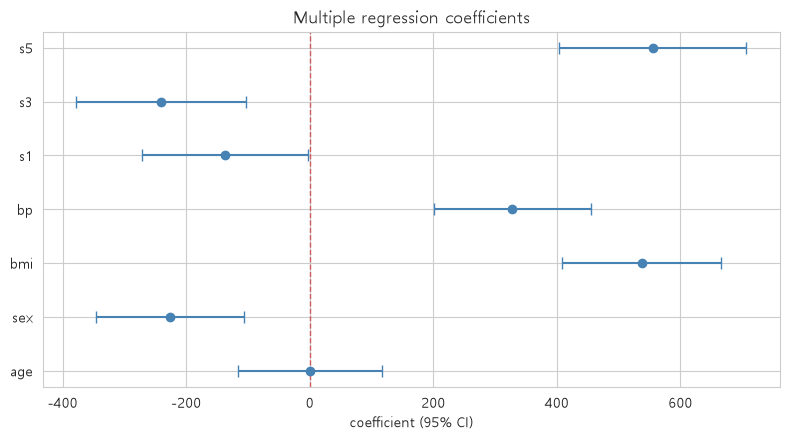

In [19]:
# [C14] 계수와 95% 신뢰구간을 한눈에 — forest plot (개념 도식: matplotlib 직접 구성)
params = mfit.params.drop("const")
ci = mfit.conf_int().drop("const")                                # 계수의 95% 신뢰구간
fig, ax = plt.subplots(figsize=(8, 4.5))                          # 그래프 하나를 그릴 도화지 준비
yloc = np.arange(len(params))                                     # 정수 눈금 배열 생성
ax.errorbar(params.values, yloc,                                  # 오차막대(신뢰구간) 표시
            xerr=[params.values - ci[0].values, ci[1].values - params.values],
            fmt="o", color="steelblue", capsize=4)
ax.axvline(0, color="indianred", ls="--", lw=1)     # 0 = 효과 없음
ax.set_yticks(yloc); ax.set_yticklabels(params.index)
ax.set_xlabel("coefficient (95% CI)"); ax.set_title("Multiple regression coefficients")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

In [20]:
# [C14b] 통제의 위력 — 단순 회귀 vs 다중 회귀에서 같은 계수가 어떻게 달라지나
simple = smf.ols("testscr ~ str_ratio", data=ca).fit()
multi  = smf.ols("testscr ~ str_ratio + english + lunch + income", data=ca).fit()

print("[단순 회귀] testscr ~ str_ratio")
print(simple.summary().tables[1])                                 # 회귀 결과에서 '계수 표'만 출력
print(f"R² = {simple.rsquared:.3f}")

print("\n[다중 회귀] + english + lunch + income (학생 배경 통제)")
print(multi.summary().tables[1])                                  # 회귀 결과에서 '계수 표'만 출력
print(f"R² = {multi.rsquared:.3f},  조정 R² = {multi.rsquared_adj:.3f}")  # 조정 R² — 변수 수에 벌점을 준 값

b_s, b_m = simple.params["str_ratio"], multi.params["str_ratio"]
print(f"\n학생-교사비 계수:  단순 {b_s:.2f}  →  통제 후 {b_m:.2f}"
      f"   ({(1 - b_m/b_s):.0%} 축소)")
print("해석: 학생 1명당 교사를 줄일 때의 '점수 하락'이, 학생 배경을 통제하면 훨씬 작아집니다.")

[단순 회귀] testscr ~ str_ratio


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    698.9329      9.467     73.825      0.000     680.323     717.543
str_ratio     -2.2798      0.480     -4.751      0.000      -3.223      -1.337
R² = 0.051

[다중 회귀] + english + lunch + income (학생 배경 통제)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    675.6082      5.309    127.261      0.000     665.173     686.044
str_ratio     -0.5604      0.229     -2.451      0.015      -1.010      -0.111
english       -0.1943      0.031     -6.193      0.000      -0.256      -0.133
lunch         -0.3964      0.027    -14.461      0.000      -0.450      -0.342
income         0.6750      0.083      8.100      0.000       0.511       0.839
R² = 0.805,  조정 R² = 0.803

학생-교사비 계수:  단순 -2.28  →  통제 후 -0.56   (75% 축소

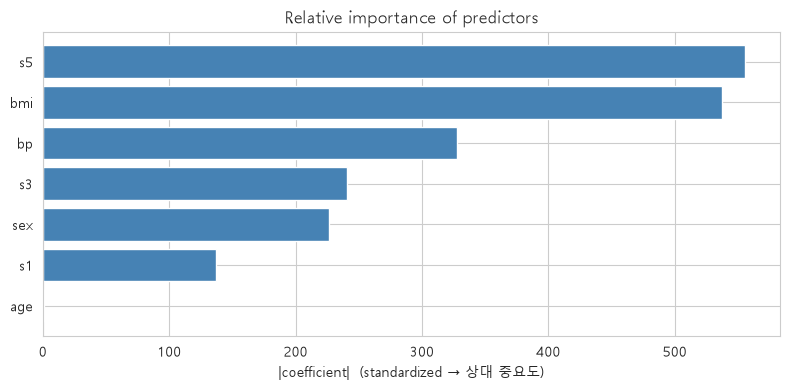

가장 크게 기여하는 변수: s5 (|계수| 556)


In [21]:
# [C15] 표준화 계수의 절댓값 = 상대적 기여도 (diabetes는 이미 표준화돼 있음)
imp = mfit.params.drop("const").abs().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))                            # 그래프 하나를 그릴 도화지 준비
ax.barh(imp.index, imp.values, color="steelblue")                 # 가로 막대그래프
ax.set_xlabel("|coefficient|  (standardized → 상대 중요도)")
ax.set_title("Relative importance of predictors")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력
print("가장 크게 기여하는 변수:", imp.index[-1], f"(|계수| {imp.values[-1]:.0f})")

In [22]:
# 1) 다중 회귀의 bmi 계수 vs 단순 회귀(Part 5)의 bmi 계수 비교

# 단순 회귀 (Part 5, C9): target ~ bmi 단독
X_simple = sm.add_constant(df["bmi"])
model_simple = sm.OLS(df["target"], X_simple).fit()
bmi_coef_simple = model_simple.params["bmi"]

# 다중 회귀: target ~ bmi + 나머지 변수들 모두
X_multi = sm.add_constant(df.drop(columns=["target"]))
model_multi = sm.OLS(df["target"], X_multi).fit()
bmi_coef_multi = model_multi.params["bmi"]

# 나란히 비교
print(f"{'모델':20}{'bmi 계수':>15}")
print("-" * 35)
print(f"{'단순 회귀 (bmi만)':20}{bmi_coef_simple:>15.2f}")
print(f"{'다중 회귀 (전체 변수)':20}{bmi_coef_multi:>15.2f}")
print(f"\n계수 차이: {bmi_coef_simple - bmi_coef_multi:.2f}")
print(f"변화율: {(bmi_coef_multi - bmi_coef_simple) / bmi_coef_simple * 100:.1f}%")

모델                           bmi 계수
-----------------------------------
단순 회귀 (bmi만)                 949.44
다중 회귀 (전체 변수)                519.85

계수 차이: 429.59
변화율: -45.2%


In [23]:
# bmi 계수가 왜 줄었는지 실제 원인 변수 찾기

# 1) 각 변수가 target과 얼마나 관련있는지
corr_with_target = df.drop(columns=["target"]).corrwith(df["target"]).sort_values(key=abs, ascending=False)
print("각 변수 - target 상관:")
print(corr_with_target.round(3))

print()

# 2) 각 변수가 bmi와 얼마나 겹치는지
corr_with_bmi = df.drop(columns=["target", "bmi"]).corrwith(df["bmi"]).sort_values(key=abs, ascending=False)
print("각 변수 - bmi 상관:")
print(corr_with_bmi.round(3))

print()

# 3) 두 조건을 동시에 만족하는 "진짜 원인" 변수 찾기
overlap = pd.DataFrame({
    "target과 상관": corr_with_target,
    "bmi와 상관": corr_with_bmi
})
overlap["종합 영향력"] = overlap["target과 상관"].abs() * overlap["bmi와 상관"].abs()
print("bmi 계수 축소에 기여한 정도 (두 상관의 곱):")
print(overlap.sort_values("종합 영향력", ascending=False).round(3))

각 변수 - target 상관:
bmi    0.586
s5     0.566
bp     0.441
s4     0.430
s3    -0.395
s6     0.382
s1     0.212
age    0.188
s2     0.174
sex    0.043
dtype: float64

각 변수 - bmi 상관:
s5     0.446
s4     0.414
bp     0.395
s6     0.389
s3    -0.367
s2     0.261
s1     0.250
age    0.185
sex    0.088
dtype: float64

bmi 계수 축소에 기여한 정도 (두 상관의 곱):
     target과 상관  bmi와 상관  종합 영향력
s5        0.566    0.446   0.252
s4        0.430    0.414   0.178
bp        0.441    0.395   0.175
s6        0.382    0.389   0.149
s3       -0.395   -0.367   0.145
s1        0.212    0.250   0.053
s2        0.174    0.261   0.045
age       0.188    0.185   0.035
sex       0.043    0.088   0.004
bmi       0.586      NaN     NaN


In [24]:
# [C17] VIF 계산 — longley 데이터 (다중공선성 교과서)
Xl = sm.add_constant(longley[["GNP", "GNPDEFL", "UNEMP", "ARMED", "POP", "YEAR"]])  # 절편(β0)을 위해 상수항 1 열을 추가
vif = pd.DataFrame({
    "변수": Xl.columns,
    "VIF": [variance_inflation_factor(Xl.values, i) for i in range(Xl.shape[1])]  # VIF — 5~10 넘으면 다중공선성 의심
})
print(vif.to_string(index=False))
print("\n→ GNP·POP·YEAR·GNPDEFL의 VIF가 수백~수천! 서로 거의 같은 정보(시간 추세)를 담고 있습니다.")

     변수          VIF
  const 1.364980e+08
    GNP 1.788513e+03
GNPDEFL 1.355324e+02
  UNEMP 3.361889e+01
  ARMED 3.588930e+00
    POP 3.991510e+02
   YEAR 7.589806e+02

→ GNP·POP·YEAR·GNPDEFL의 VIF가 수백~수천! 서로 거의 같은 정보(시간 추세)를 담고 있습니다.


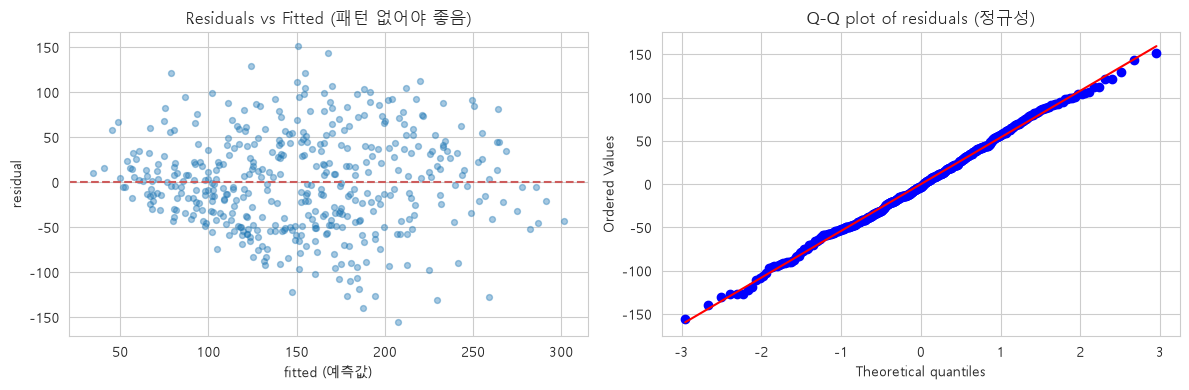

In [26]:
# [C18] 잔차 진단 — diabetes 다중회귀의 잔차 두 그림
resid = mfit.resid; fitted = mfit.fittedvalues                    # 회귀가 예측한 값(적합값)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))                   # 그림 한 장에 그래프 2개(1행 2열)
# (1) 잔차 vs 적합값 — 패턴/깔때기가 없어야 건강
axes[0].scatter(fitted, resid, alpha=0.4, s=18)
axes[0].axhline(0, color="indianred", ls="--")                    # 가로 기준선 표시
axes[0].set_xlabel("fitted (예측값)"); axes[0].set_ylabel("residual")
axes[0].set_title("Residuals vs Fitted (패턴 없어야 좋음)")
# (2) 잔차 Q-Q plot — 직선에 붙어야 정규
stats.probplot(resid, dist="norm", plot=axes[1])                  # Q-Q plot — 점이 직선에 붙을수록 그 분포에 가깝다
axes[1].set_title("Q-Q plot of residuals (정규성)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

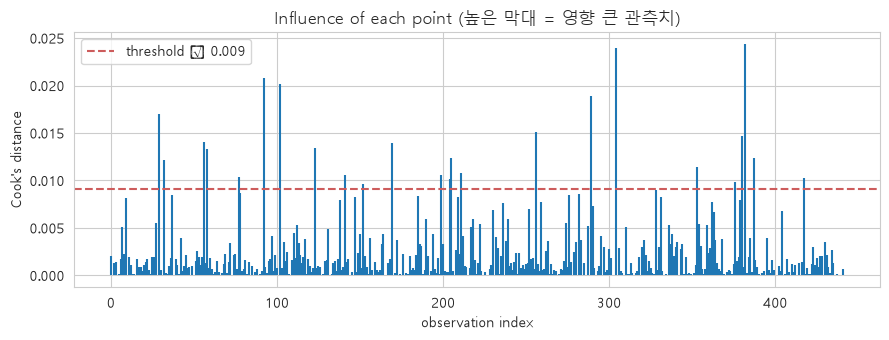

임계값 초과 관측치 수: 24개  (이들이 계수를 크게 좌우할 수 있음)


In [27]:
# [C19] 진단 ③ 이상치 영향 — Cook's distance (한 점이 회귀선을 흔드나)
infl = mfit.get_influence()                                       # 영향점 진단용 객체 (Cook's distance 등)
cooks = infl.cooks_distance[0]
fig, ax = plt.subplots(figsize=(9, 3.5))                          # 그래프 하나를 그릴 도화지 준비
ax.stem(np.arange(len(cooks)), cooks, markerfmt=" ", basefmt=" ")  # 관측치별 값을 막대로 — 튀는 점 찾기
thresh = 4 / len(cooks)        # 흔한 경험적 임계값
ax.axhline(thresh, color="indianred", ls="--", label=f"threshold ≈ {thresh:.3f}")  # 가로 기준선 표시
ax.set_xlabel("observation index"); ax.set_ylabel("Cook's distance")
ax.set_title("Influence of each point (높은 막대 = 영향 큰 관측치)"); ax.legend()
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력
print(f"임계값 초과 관측치 수: {(cooks > thresh).sum()}개  (이들이 계수를 크게 좌우할 수 있음)")

In [28]:
# [C20] 등분산 검정 — Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_p, _, _ = het_breuschpagan(mfit.resid, mfit.model.exog)  # Breusch-Pagan 등분산 검정 — p가 작으면 이분산
print(f"Breusch-Pagan: LM 통계량 = {bp_stat:.2f}, p = {bp_p:.4f}")
print("H0: 등분산이다 →", "이분산 의심 (p<0.05)" if bp_p < 0.05 else "등분산으로 볼 만함 (p>=0.05)")
print("\n→ 이분산이 의심되면 robust 표준오차(cov_type='HC3')로 다시 적합해 p값을 보정합니다.")  # 이분산에 강한(robust) 표준오차 — 계수는 그대로, SE만 보정

Breusch-Pagan: LM 통계량 = 21.99, p = 0.0025
H0: 등분산이다 → 이분산 의심 (p<0.05)

→ 이분산이 의심되면 robust 표준오차(cov_type='HC3')로 다시 적합해 p값을 보정합니다.


[engel] Breusch-Pagan: LM = 109.3, p = 1.42e-25  → 이분산 (등분산 기각)

[income 계수의 불확실성 — 기본 vs robust]
                 계수(coef)  표준오차(SE)        t  95% CI 하한  95% CI 상한
기본 SE              0.4852    0.0144  33.7718     0.4569     0.5135
robust SE (HC3)    0.4852    0.0664   7.3081     0.3551     0.6153


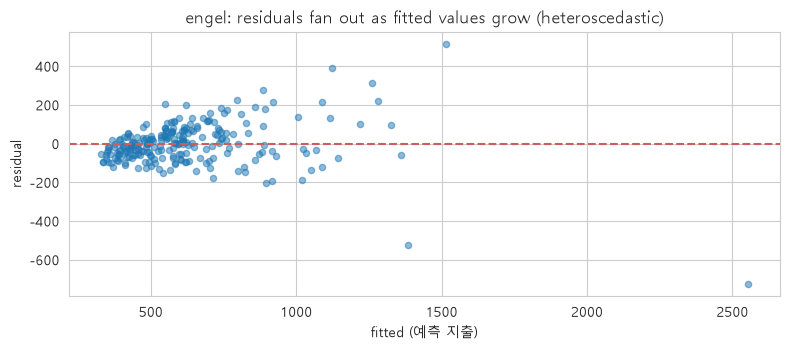

In [29]:
# [C20b] 이분산 실사례 — engel(소득→식료품 지출)에서 진단하고 robust SE로 대응
from statsmodels.stats.diagnostic import het_breuschpagan

me = sm.OLS(engel["foodexp"], sm.add_constant(engel["income"])).fit()  # 절편(β0)을 위해 상수항 1 열을 추가
bp_stat_e, bp_p_e, _, _ = het_breuschpagan(me.resid, me.model.exog)  # Breusch-Pagan 등분산 검정 — p가 작으면 이분산
print(f"[engel] Breusch-Pagan: LM = {bp_stat_e:.1f}, p = {bp_p_e:.2e}"
      f"  → {'이분산 (등분산 기각)' if bp_p_e < 0.05 else '등분산으로 볼 만함'}")

# 같은 모형을 robust(HC3) 표준오차로 다시 적합 — 계수는 그대로, SE만 바뀐다
me_rob = sm.OLS(engel["foodexp"], sm.add_constant(engel["income"])).fit(cov_type="HC3")  # 절편(β0)을 위해 상수항 1 열을 추가
comp = pd.DataFrame({
    "계수(coef)":      [me.params["income"],     me_rob.params["income"]],
    "표준오차(SE)":     [me.bse["income"],        me_rob.bse["income"]],
    "t":               [me.tvalues["income"],    me_rob.tvalues["income"]],
    "95% CI 하한":      [me.conf_int().loc["income", 0], me_rob.conf_int().loc["income", 0]],  # 계수의 95% 신뢰구간
    "95% CI 상한":      [me.conf_int().loc["income", 1], me_rob.conf_int().loc["income", 1]],  # 계수의 95% 신뢰구간
}, index=["기본 SE", "robust SE (HC3)"]).round(4)
print("\n[income 계수의 불확실성 — 기본 vs robust]")
print(comp.to_string())

fig, ax = plt.subplots(figsize=(8, 3.6))                          # 그래프 하나를 그릴 도화지 준비
ax.scatter(me.fittedvalues, me.resid, alpha=0.5, s=20)            # 회귀가 예측한 값(적합값)
ax.axhline(0, color="indianred", ls="--")                         # 가로 기준선 표시
ax.set_xlabel("fitted (예측 지출)"); ax.set_ylabel("residual")
ax.set_title("engel: residuals fan out as fitted values grow (heteroscedastic)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

In [31]:
import statsmodels.api as sm

# longley 데이터 다시 로드
longley = sm.datasets.longley.load_pandas().data
print(longley.shape, list(longley.columns))

(16, 7) ['TOTEMP', 'GNPDEFL', 'GNP', 'UNEMP', 'ARMED', 'POP', 'YEAR']


In [33]:
# 1) longley에서 VIF가 가장 큰 변수 하나를 빼고 다시 VIF 계산

import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# longley 데이터: Employed(고용자수)를 종속변수로, 나머지를 독립변수로 사용
print("longley 컬럼:", list(longley.columns))

X_full = longley.drop(columns=["TOTEMP"])   # 독립변수만
X_full_const = sm.add_constant(X_full)

# 최초 VIF 계산
vif_before = pd.DataFrame()
vif_before["변수"] = X_full_const.columns
vif_before["VIF"] = [variance_inflation_factor(X_full_const.values, i)
                      for i in range(X_full_const.shape[1])]

print("=== 변수 제거 전 VIF ===")
print(vif_before.round(2))

# const(상수항)는 제외하고, 가장 VIF 높은 변수 찾기
vif_no_const = vif_before[vif_before["변수"] != "const"]
worst_var = vif_no_const.loc[vif_no_const["VIF"].idxmax(), "변수"]
worst_vif = vif_no_const["VIF"].max()

print(f"\nVIF가 가장 큰 변수: {worst_var} (VIF = {worst_vif:.2f}) → 제거")

longley 컬럼: ['TOTEMP', 'GNPDEFL', 'GNP', 'UNEMP', 'ARMED', 'POP', 'YEAR']
=== 변수 제거 전 VIF ===
        변수           VIF
0    const  1.364980e+08
1  GNPDEFL  1.355300e+02
2      GNP  1.788510e+03
3    UNEMP  3.362000e+01
4    ARMED  3.590000e+00
5      POP  3.991500e+02
6     YEAR  7.589800e+02

VIF가 가장 큰 변수: GNP (VIF = 1788.51) → 제거


In [34]:
# 2) 해당 변수를 제거하고 남은 변수들의 VIF 재계산 → 줄어드는지 비교

X_reduced = X_full.drop(columns=[worst_var])
X_reduced_const = sm.add_constant(X_reduced)

vif_after = pd.DataFrame()
vif_after["변수"] = X_reduced_const.columns
vif_after["VIF"] = [variance_inflation_factor(X_reduced_const.values, i)
                     for i in range(X_reduced_const.shape[1])]

print(f"=== '{worst_var}' 제거 후 VIF ===")
print(vif_after.round(2))

# 제거 전/후 비교 (공통 변수만)
comparison = vif_before[vif_before["변수"] != worst_var].merge(
    vif_after, on="변수", suffixes=("_제거전", "_제거후")
)
comparison["변화량"] = comparison["VIF_제거후"] - comparison["VIF_제거전"]

print("\n=== 제거 전후 VIF 비교 ===")
print(comparison.round(2))

=== 'GNP' 제거 후 VIF ===
        변수          VIF
0    const  45583838.57
1  GNPDEFL        78.37
2    UNEMP         3.56
3    ARMED         2.80
4      POP       122.05
5     YEAR       271.19

=== 제거 전후 VIF 비교 ===
        변수       VIF_제거전      VIF_제거후          변화량
0    const  1.364980e+08  45583838.57 -90914123.33
1  GNPDEFL  1.355300e+02        78.37       -57.16
2    UNEMP  3.362000e+01         3.56       -30.06
3    ARMED  3.590000e+00         2.80        -0.79
4      POP  3.991500e+02       122.05      -277.10
5     YEAR  7.589800e+02       271.19      -487.79


In [35]:
# 남은 변수들끼리 상관관계 확인해보기
print(longley[["GNPDEFL", "POP", "YEAR", "UNEMP", "ARMED"]].corr().round(3))

         GNPDEFL    POP   YEAR  UNEMP  ARMED
GNPDEFL    1.000  0.979  0.991  0.621  0.465
POP        0.979  1.000  0.994  0.687  0.364
YEAR       0.991  0.994  1.000  0.668  0.417
UNEMP      0.621  0.687  0.668  1.000 -0.177
ARMED      0.465  0.364  0.417 -0.177  1.000


In [36]:
# YEAR 혹은 POP 중 하나 더 제거해보기
X_reduced2 = X_reduced.drop(columns=["YEAR"])  # 예: YEAR 추가 제거
X_reduced2_const = sm.add_constant(X_reduced2)

vif_2 = pd.DataFrame()
vif_2["변수"] = X_reduced2_const.columns
vif_2["VIF"] = [variance_inflation_factor(X_reduced2_const.values, i)
                for i in range(X_reduced2_const.shape[1])]
print(vif_2.round(2))

        변수      VIF
0    const  2359.45
1  GNPDEFL    35.97
2    UNEMP     3.15
3    ARMED     2.50
4      POP    34.59


In [37]:
# [C22] 한 얼굴 맛보기 — 회귀로 t-test를 그대로 재현 (얼굴 ②의 증거)
# diabetes의 sex(0/1 비슷한 이분 변수)로 target 차이를 (a) t-test와 (b) 회귀로
grp = (df["sex"] > df["sex"].median()).astype(int)     # 두 그룹으로 이분
g0 = df.loc[grp == 0, "target"]; g1 = df.loc[grp == 1, "target"]
t_res = stats.ttest_ind(g1, g0)                                   # 두 독립 집단의 평균 비교 (equal_var=False면 Welch)
reg = sm.OLS(df["target"], sm.add_constant(grp.rename("group"))).fit()  # 절편(β0)을 위해 상수항 1 열을 추가
print(f"(a) t-test    : t = {t_res.statistic:.3f}, p = {t_res.pvalue:.4f}")
print(f"(b) 회귀 group계수: {reg.params['group']:.1f}, t = {reg.tvalues['group']:.3f}, p = {reg.pvalues['group']:.4f}")
print("→ 회귀의 group 계수 t/p가 t-test와 (거의) 일치! t-test는 회귀의 특수한 경우입니다.")

(a) t-test    : t = 0.904, p = 0.3664
(b) 회귀 group계수: 6.6, t = 0.904, p = 0.3664
→ 회귀의 group 계수 t/p가 t-test와 (거의) 일치! t-test는 회귀의 특수한 경우입니다.


In [38]:
# [C23] 한 걸음 더 — 여러 집단(범주형)을 넣으면 회귀가 ANOVA가 된다
df["_grp"] = pd.qcut(df["bmi"], 3, labels=["low", "mid", "high"])     # bmi를 3구간 범주로
groups = [g["target"].values for _, g in df.groupby("_grp", observed=True)]  # 집단별로 묶어서 계산
f_anova, p_anova = stats.f_oneway(*groups)                        # 일원 ANOVA — F = 집단 간 분산 / 집단 내 분산
dummies = pd.get_dummies(df["_grp"], drop_first=True).astype(float)  # 범주형을 0/1 더미 변수로 변환
reg_cat = sm.OLS(df["target"], sm.add_constant(dummies)).fit()    # 절편(β0)을 위해 상수항 1 열을 추가
print(f"(a) 일원 ANOVA   : F = {f_anova:.2f}, p = {p_anova:.2e}")
print(f"(b) 범주형 회귀  : F = {reg_cat.fvalue:.2f}, p = {reg_cat.f_pvalue:.2e}")
print("→ 회귀의 F-검정이 ANOVA와 일치! ANOVA도 회귀의 특수한 경우입니다.")
df.drop(columns="_grp", inplace=True)

(a) 일원 ANOVA   : F = 95.40, p = 3.95e-35
(b) 범주형 회귀  : F = 95.40, p = 3.95e-35
→ 회귀의 F-검정이 ANOVA와 일치! ANOVA도 회귀의 특수한 경우입니다.


In [39]:
# [C24] [1] diabetes 다중회귀 (핵심 변수)
feat = ["bmi", "bp", "s5", "s3", "age"]
Xf = sm.add_constant(df[feat]); yf = df["target"]                 # 절편(β0)을 위해 상수항 1 열을 추가
fin = sm.OLS(yf, Xf).fit()                                        # 최소제곱 회귀 적합
print("[1] 회귀 계수")
print(fin.summary().tables[1])                                    # 회귀 결과에서 '계수 표'만 출력
print(f"\nR² = {fin.rsquared:.3f}, 조정 R² = {fin.rsquared_adj:.3f}, F p = {fin.f_pvalue:.2e}")  # 조정 R² — 변수 수에 벌점을 준 값

[1] 회귀 계수
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.628     57.880      0.000     146.968     157.299
bmi          556.0419     65.879      8.440      0.000     426.562     685.522
bp           280.4990     64.414      4.355      0.000     153.898     407.100
s5           492.1581     67.553      7.285      0.000     359.388     624.929
s3          -191.9232     62.032     -3.094      0.002    -313.842     -70.005
age          -40.5116     59.495     -0.681      0.496    -157.445      76.422

R² = 0.492, 조정 R² = 0.486, F p = 6.31e-62


In [40]:
# [C25] [2] VIF 점검  (이 모델의 설명변수끼리 얼마나 얽혔나)
vif_f = pd.DataFrame({"변수": Xf.columns,
    "VIF": [variance_inflation_factor(Xf.values, i) for i in range(Xf.shape[1])]})  # VIF — 5~10 넘으면 다중공선성 의심
print("[2] VIF (const 제외하고 해석)")
print(vif_f.to_string(index=False))

[2] VIF (const 제외하고 해석)
   변수      VIF
const 1.000000
  bmi 1.421284
   bp 1.358791
   s5 1.494443
   s3 1.260134
  age 1.159191


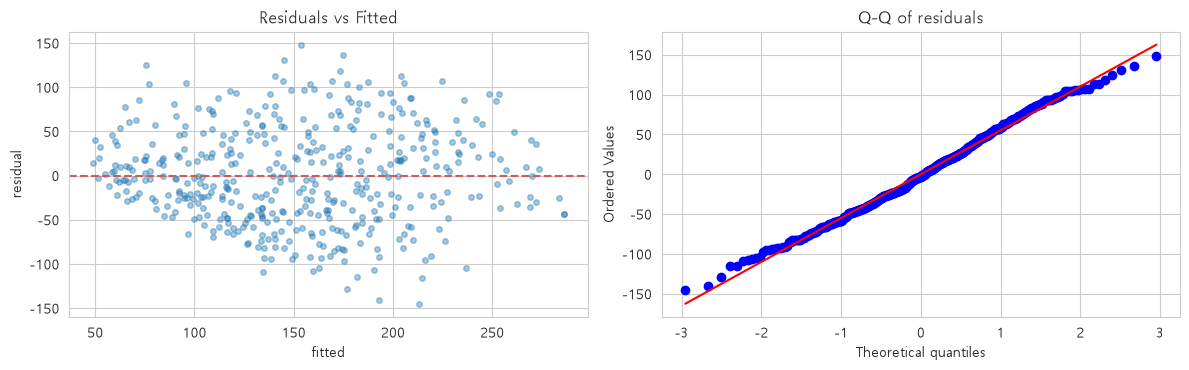

정규성(잔차) Shapiro p = 0.061


In [41]:
# [C26] [3] 잔차 진단 (가정 점검)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))                 # 그림 한 장에 그래프 2개(1행 2열)
axes[0].scatter(fin.fittedvalues, fin.resid, alpha=0.4, s=16); axes[0].axhline(0, color="indianred", ls="--")  # 가로 기준선 표시
axes[0].set_title("Residuals vs Fitted"); axes[0].set_xlabel("fitted"); axes[0].set_ylabel("residual")
stats.probplot(fin.resid, dist="norm", plot=axes[1]); axes[1].set_title("Q-Q of residuals")  # Q-Q plot — 점이 직선에 붙을수록 그 분포에 가깝다
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력
print("정규성(잔차) Shapiro p =", round(stats.shapiro(fin.resid).pvalue, 3))  # 정규성 검정 — H0: 정규분포를 따른다

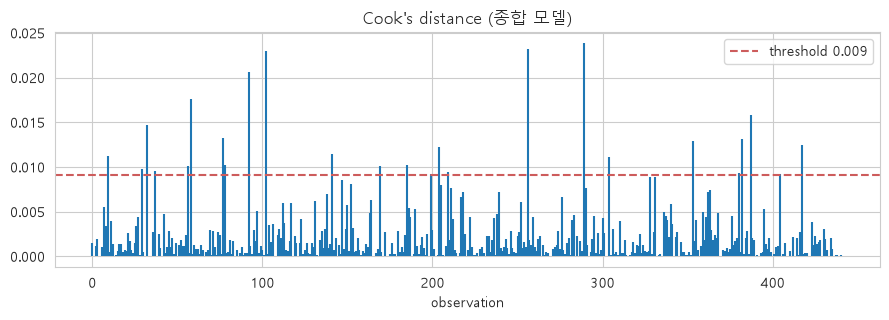

영향점(임계 초과): 25개 — 이들을 빼면 결론이 바뀌는지 점검하면 좋습니다.


In [43]:
# [C27] [4] 영향점 — Cook's distance로 회귀를 흔드는 관측치 찾기
infl = fin.get_influence(); cooks = infl.cooks_distance[0]        # 영향점 진단용 객체 (Cook's distance 등)
thr = 4 / len(cooks)
fig, ax = plt.subplots(figsize=(9, 3.3))                          # 그래프 하나를 그릴 도화지 준비
ax.stem(np.arange(len(cooks)), cooks, markerfmt=" ", basefmt=" ")  # 관측치별 값을 막대로 — 튀는 점 찾기
ax.axhline(thr, color="indianred", ls="--", label=f"threshold {thr:.3f}")  # 가로 기준선 표시
ax.set_title("Cook's distance (종합 모델)"); ax.set_xlabel("observation"); ax.legend()
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력
print(f"영향점(임계 초과): {(cooks > thr).sum()}개 — 이들을 빼면 결론이 바뀌는지 점검하면 좋습니다.")

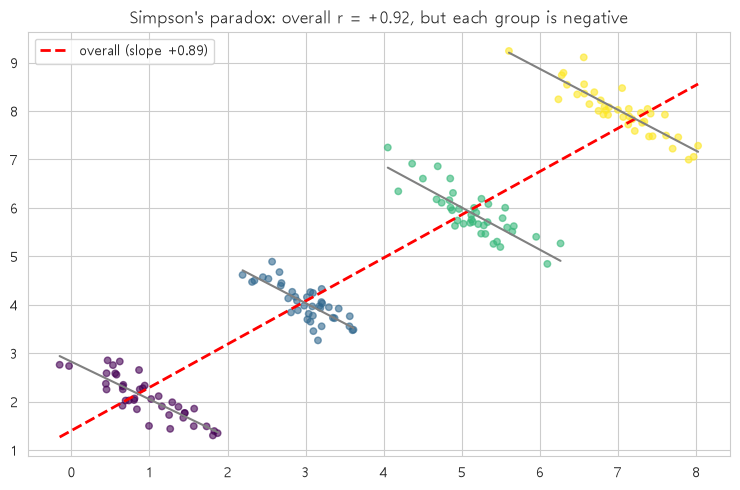

전체 상관 = +0.92 (양)  /  각 집단 안에서는 모두 음(-)의 관계


In [44]:
# [C28] 심슨의 역설 — 전체는 양(+), 집단 안에서는 음(-)
np.random.seed(1)                                                 # 재현성: 난수를 항상 같게 고정
xs, ys, gs = [], [], []
for k, (cx, cy) in enumerate([(1, 2), (3, 4), (5, 6), (7, 8)]):   # 집단 중심은 우상향(전체 +)
    gx = np.random.normal(cx, 0.5, 40)
    gy = cy - 0.8 * (gx - cx) + np.random.normal(0, 0.25, 40)      # 집단 안은 음의 기울기
    xs += gx.tolist(); ys += gy.tolist(); gs += [k] * 40
xs, ys, gs = np.array(xs), np.array(ys), np.array(gs)

r_all = stats.pearsonr(xs, ys)[0]                                 # Pearson 상관 — '직선' 관계의 세기 (-1~1)
fig, ax = plt.subplots(figsize=(7.5, 5))                          # 그래프 하나를 그릴 도화지 준비
ax.scatter(xs, ys, c=gs, cmap="viridis", alpha=0.6, s=22)
# 전체 회귀선 (양)
b1, b0 = np.polyfit(xs, ys, 1)
gxr = np.array([xs.min(), xs.max()]); ax.plot(gxr, b0 + b1*gxr, "r--", lw=2, label=f"overall (slope {b1:+.2f})")
# 집단별 회귀선 (음)
for k in range(4):
    mask = gs == k
    bb1, bb0 = np.polyfit(xs[mask], ys[mask], 1)
    gg = np.array([xs[mask].min(), xs[mask].max()]); ax.plot(gg, bb0 + bb1*gg, color="gray", lw=1.5)
ax.set_title(f"Simpson's paradox: overall r = {r_all:+.2f}, but each group is negative")
ax.legend(); plt.tight_layout(); plt.show()                       # 그래프 간격 자동 정리 후 출력
print(f"전체 상관 = {r_all:+.2f} (양)  /  각 집단 안에서는 모두 음(-)의 관계")

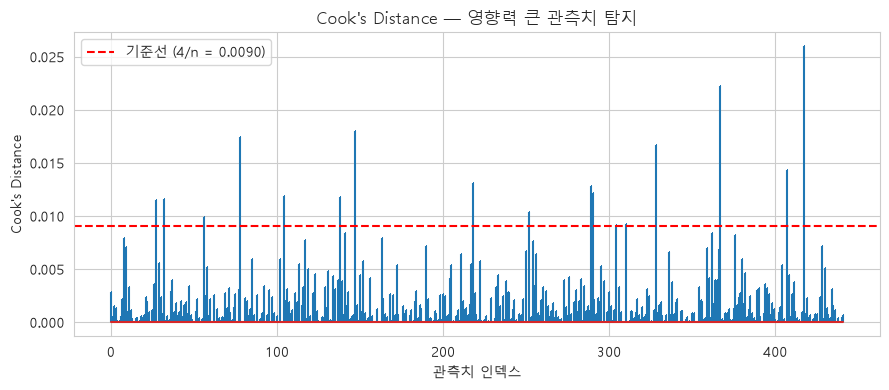

영향력이 큰 관측치 개수: 17 / 442
해당 인덱스: [ 27  32  56  78 104 138 147 218 252 289]...


In [45]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

X = sm.add_constant(df["bmi"])
model = sm.OLS(df["target"], X).fit()

# Cook's distance 계산
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]   # (거리값, p-value) 튜플 중 첫 번째

# 기준값
n = len(df)
threshold = 4 / n

# 시각화
plt.figure(figsize=(9, 4))
plt.stem(range(n), cooks_d, markerfmt=",")
plt.axhline(threshold, color="red", linestyle="--", label=f"기준선 (4/n = {threshold:.4f})")
plt.xlabel("관측치 인덱스")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance — 영향력 큰 관측치 탐지")
plt.legend()
plt.tight_layout()
plt.show()

# 기준을 넘는 관측치 확인
influential_points = np.where(cooks_d > threshold)[0]
print(f"영향력이 큰 관측치 개수: {len(influential_points)} / {n}")
print(f"해당 인덱스: {influential_points[:10]}...")  # 처음 10개만 출력

In [46]:
# 가장 영향력 큰 관측치 하나 빼고 재적합 비교
worst_idx = np.argmax(cooks_d)
df_removed = df.drop(index=worst_idx)

model_removed = sm.OLS(df_removed["target"], sm.add_constant(df_removed["bmi"])).fit()

print(f"제거 전 bmi coef: {model.params['bmi']:.2f}")
print(f"관측치 {worst_idx} 제거 후 bmi coef: {model_removed.params['bmi']:.2f}")

제거 전 bmi coef: 949.44
관측치 417 제거 후 bmi coef: 961.30
